In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def predict(w, x, b):
    return np.dot(w, x) + b
# predict(np.array([8.6, 2.1]), np.array([8.6, 2.1]), 1)

def compute_cost(X, Y, w, b):
    m = len(X)
    total_cost = 0
    
    for i in range(m):
        error = predict(w, X[i], b) - Y[i]
        total_cost += error ** 2
    
    cost = total_cost / (2 * m)
    return cost

def compute_gradient(X, Y, w, b):
    m = len(X)
    dw = np.zeros_like(w)
    db = 0
    
    for i in range(m):
        error = predict(w, X[i], b) - Y[i]
        dw += error * X[i]
        db += error
    
    return dw / m, db / m

def gradient_descent(X, Y, w, b, learning_rate, iterations):
    cost_history = []
    w = w.copy()  # avoid mutating the caller's array
    
    for i in range(iterations):
        dw, db = compute_gradient(X, Y, w, b)
        
        w = w - learning_rate * dw  # reassign instead of in-place mutate
        b = b - learning_rate * db
        
        if i % 100 == 0:
            cost = compute_cost(X, Y, w, b)
            cost_history.append(cost)
            print(f"Iteration {i:4d}: Cost = {cost:.6f}")
    
    return w, b, cost_history

# 1. Load and normalize FIRST
df = pd.read_csv("advertising.csv")
df["total"]             = df["TV"] + df["Radio"] + df["Newspaper"]
df["TV_portion"]        = df["TV"]        / df["total"]
df["Radio_portion"]     = df["Radio"]     / df["total"]
df["Newspaper_portion"] = df["Newspaper"] / df["total"]


df.drop(columns=["total"], inplace=True)  # drop total as it's not a feature we want to use
df["TV"]        = (df["TV"]        - df["TV"].mean())        / df["TV"].std()
df["Radio"]     = (df["Radio"]     - df["Radio"].mean())     / df["Radio"].std()
df["Newspaper"] = (df["Newspaper"] - df["Newspaper"].mean()) / df["Newspaper"].std()
df["TV_portion"] = (df["TV_portion"] - df["TV_portion"].mean()) / df["TV_portion"].std()
df["Radio_portion"] = (df["Radio_portion"] - df["Radio_portion"].mean()) / df["Radio_portion"].std()
df["Newspaper_portion"] = (df["Newspaper_portion"] - df["Newspaper_portion"].mean()) / df["Newspaper_portion"].std()

# 2. Then split
train_data = df.sample(frac=0.8, random_state=42)
X_train = train_data[["TV", "Radio", "Newspaper", "TV_portion", "Radio_portion", "Newspaper_portion"]].values
Y_train = train_data["Sales"].values

test_data = df.drop(train_data.index)
X_test = test_data[["TV", "Radio", "Newspaper", "TV_portion", "Radio_portion", "Newspaper_portion"]].values
Y_test = test_data["Sales"].values

# 3. Then train with a normal learning rate
initial_cost = compute_cost(X_train, Y_train, np.zeros(X_train.shape[1]), 0)
print(f"Initial Cost: {initial_cost:.6f}")

w = np.zeros(X_train.shape[1])
b = 0
w, b, cost_history = gradient_descent(X_train, Y_train, w, b, learning_rate=0.01, iterations=1000)
print(w)
print(b)


Initial Cost: 126.771938
Iteration    0: Cost = 123.866248
Iteration  100: Cost = 16.048055
Iteration  200: Cost = 2.975683
Iteration  300: Cost = 1.213410
Iteration  400: Cost = 0.967664
Iteration  500: Cost = 0.928193
Iteration  600: Cost = 0.917784
Iteration  700: Cost = 0.912191
Iteration  800: Cost = 0.907934
Iteration  900: Cost = 0.904394
[ 2.3061794   1.17676553  0.6898645   0.79155949 -0.5024646  -0.75163497
  1.39320931]
15.079672248100941


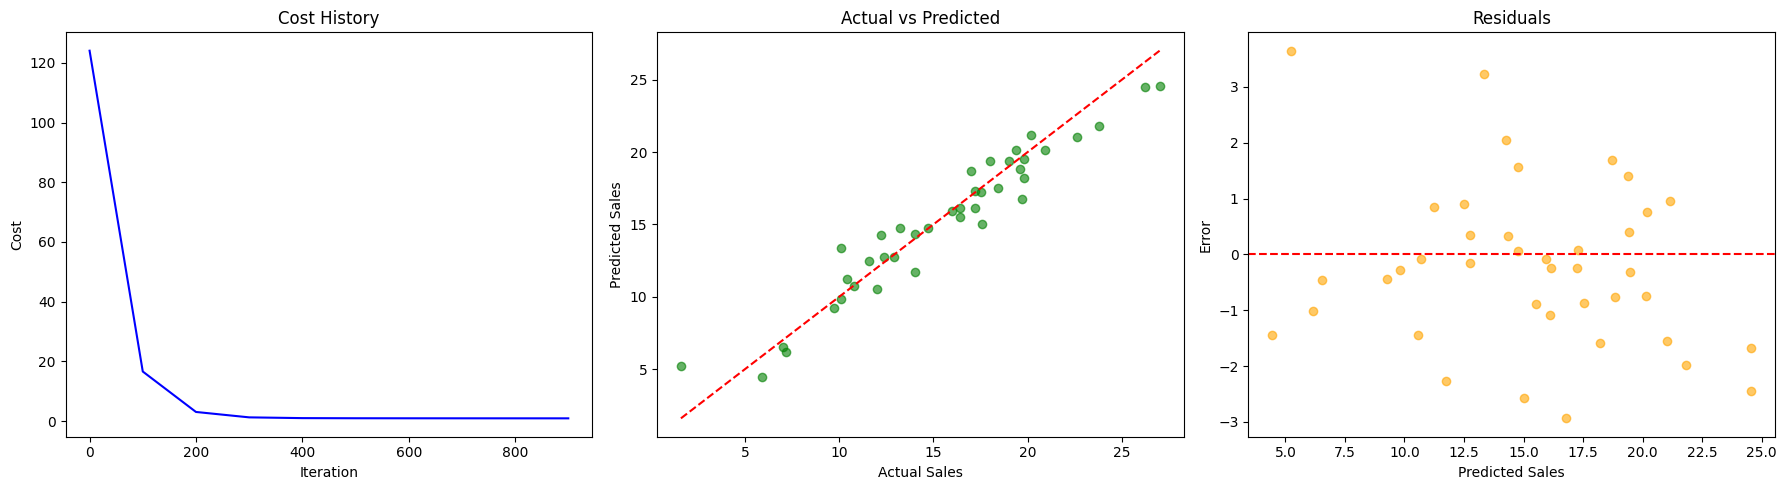

In [60]:
# Generate test predictions
Y_pred = []
for i in range(len(X_test)):
    Y_pred.append(predict(w, X_test[i], b))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Cost history (did it converge?)
iterations_logged = [i * 100 for i in range(len(cost_history))]
axes[0].plot(iterations_logged, cost_history, color="blue")
axes[0].set_title("Cost History")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost")

# Plot 2 — Actual vs Predicted (how close are predictions?)
axes[1].scatter(Y_test, Y_pred, color="green", alpha=0.6)
axes[1].plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color="red", linestyle="--")
axes[1].set_title("Actual vs Predicted")
axes[1].set_xlabel("Actual Sales")
axes[1].set_ylabel("Predicted Sales")

# Plot 3 — Residuals (are errors random or patterned?)
residuals = [Y_pred[i] - Y_test[i] for i in range(len(Y_test))]
axes[2].scatter(Y_pred, residuals, color="orange", alpha=0.6)
axes[2].axhline(y=0, color="red", linestyle="--")
axes[2].set_title("Residuals")
axes[2].set_xlabel("Predicted Sales")
axes[2].set_ylabel("Error")

plt.tight_layout()
plt.show()

In [63]:
def r_squared(Y, Y_pred):
    ss_res = 0
    ss_tot = 0
    y_mean = sum(Y) / len(Y)
    
    for i in range(len(Y)):
        ss_res += (Y[i] - Y_pred[i]) ** 2
        ss_tot += (Y[i] - y_mean) ** 2
    
    return 1 - (ss_res / ss_tot)

def mae(Y, Y_pred):
    total = 0
    for i in range(len(Y)):
        total += abs(Y[i] - Y_pred[i])
    return total / len(Y)

def rmse(Y, Y_pred):
    total = 0
    for i in range(len(Y)):
        total += (Y[i] - Y_pred[i]) ** 2
    return (total / len(Y)) ** 0.5

# Generate predictions for test set
Y_pred = []
for i in range(len(X_test)):
    Y_pred.append(predict(w, X_test[i], b))

print(f"R²:   {r_squared(Y_test, Y_pred):.4f}")
print(f"MAE:  {mae(Y_test, Y_pred):.4f}")
print(f"RMSE: {rmse(Y_test, Y_pred):.4f}")

R²:   0.9298
MAE:  1.1411
RMSE: 1.4392
